In [27]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats

# Output
OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Colors
CAT_COLORS = {
    'cars': '#b3cde0', 'luxury clothes': '#fbb4ae', 'other': '#d9d9d9', 
    'social media': '#ccebc5', 'electronics': '#decbe4', 'alcohol and smoke': '#fed9a6', 
    'food': '#e5d8bd', 'persons': '#fddaec', 'weapons': '#b3e2cd', 'places': '#fdcdac'
}
PASTEL_PALETTE = ['#b3cde0','#fbb4ae','#ccebc5','#decbe4','#fed9a6','#e5d8bd',
                  '#fddaec','#b3e2cd','#fdcdac','#cbd5e8','#f4cae4','#e6f5c9',
                  '#fff2ae','#f1e2cc','#f1b6da','#b8e186']

def set_minimalist_style():
    sns.set_theme(style="white", font="sans-serif")
    plt.rcParams.update({
        "font.family": "Arial",
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlepad": 15,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "legend.title_fontsize": 11,
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False
    })

def style_axis(ax, x_grid=False, y_grid=True):
    if y_grid:
        ax.yaxis.grid(True, linestyle='-', color='#f1f5f9', alpha=0.8)
        ax.set_axisbelow(True)
    if x_grid:
        ax.xaxis.grid(True, linestyle='-', color='#f1f5f9', alpha=0.8)
        ax.set_axisbelow(True)
    sns.despine(ax=ax, left=not y_grid, bottom=not x_grid)

# Data
def load_and_prep_data(filepath='../dashboard_data/df_genres v2.csv'):
    df = pd.read_csv(filepath)
    df['year'] = pd.to_datetime(df['year'], format='mixed', errors='coerce').dt.year
    df = df[df['year'] <= 2025]

    def parse_brand_data(val):
        if pd.isna(val) or val == '[]': return []
        try:
            return [{'brand': b.get('normalized'), 
                     'category': b.get('category', 'other'), 
                     'origin': b.get('origin', 'unknown')} 
                    for b in ast.literal_eval(val) if b.get('normalized')]
        except: 
            return []

    df['parsed_brands'] = df['extracted_brands'].apply(parse_brand_data)
    
    df_exploded = df.explode('parsed_brands').dropna(subset=['parsed_brands', 'year', 'matched_artist', 'matched_song'])
    df_exploded['brands'] = df_exploded['parsed_brands'].apply(lambda x: x.get('brand'))
    df_exploded['categories'] = df_exploded['parsed_brands'].apply(lambda x: x.get('category'))
    df_exploded['origins'] = df_exploded['parsed_brands'].apply(lambda x: x.get('origin'))
    
    return df, df_exploded

# Plotting
def plot_brand_ratios_over_time(df):
    unique_songs = df.drop_duplicates(subset=['matched_artist', 'matched_song']).copy()
    
    years = list(range(int(unique_songs['year'].min()), int(unique_songs['year'].max()) + 1))
    total_counts = unique_songs.groupby('year').size().reindex(years, fill_value=0)
    
    def has_western(b_list): return any(b.get('origin') == 'Western/Abroad' for b in b_list) if isinstance(b_list, list) else False
    def has_domestic(b_list): return any(b.get('origin') in ['Domestic', 'CIS'] for b in b_list) if isinstance(b_list, list) else False

    west_counts = unique_songs[unique_songs['parsed_brands'].apply(has_western)].groupby('year').size().reindex(years, fill_value=0)
    dom_counts = unique_songs[unique_songs['parsed_brands'].apply(has_domestic)].groupby('year').size().reindex(years, fill_value=0)

    df_ratios = pd.DataFrame({
        'Year': years,
        'Western/Abroad': (west_counts / total_counts * 100).fillna(0),
        'Domestic/CIS': (dom_counts / total_counts * 100).fillna(0)
    }).set_index('Year')

    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.lineplot(data=df_ratios['Western/Abroad'], ax=ax, color='#b3cde0', linewidth=2.5, label='Western/Abroad')
    sns.lineplot(data=df_ratios['Domestic/CIS'], ax=ax, color='#fbb4ae', linewidth=2.5, label='Domestic/CIS')

    # ax.set_title("Percentage of Songs Containing Brand Mentions (1991–2024)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percentage of Songs (%)")
    ax.set_ylim(0, max(df_ratios.max().max() + 5, 50)) 
    
    style_axis(ax, y_grid=True)
    plt.legend(title="Brand Origin")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "1_brand_ratios_over_time.png"), format='png', bbox_inches='tight')
    plt.show()

def plot_top_categories_stacked(df_exploded):
    counts = df_exploded.drop_duplicates(subset=['matched_artist', 'matched_song', 'categories'])
    counts = counts.groupby(['year', 'categories']).size().unstack(fill_value=0)
    
    years = list(range(int(counts.index.min()), int(counts.index.max()) + 1))
    counts = counts.reindex(years, fill_value=0)
    
    top_cats = counts.sum().nlargest(8).index
    plot_data = counts[top_cats]
    
    colors = [CAT_COLORS.get(c, '#d9d9d9') for c in plot_data.columns]

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_data.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.85)
    plot_data.to_csv(os.path.join(OUTPUT_DIR, "2_categories_over_time.csv"), index=True) 

    # ax.set_title("Frequency of Brand Categories in Lyrics Over Time")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Unique Songs")
    
    ax.set_xticks(range(0, len(years), 2))
    ax.set_xticklabels([years[i] for i in range(0, len(years), 2)], rotation=0)

    style_axis(ax, y_grid=True)
    plt.legend(title="Category", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "2_categories_stacked_bar.png"), format='png', bbox_inches='tight')
    plt.show()

def plot_top_10_brands(df_exploded):
    unique_mentions = df_exploded.drop_duplicates(subset=['matched_artist', 'matched_song', 'brands'])
    top_brands = unique_mentions['brands'].value_counts().nlargest(10).reset_index()
    top_brands.columns = ['Brand', 'Unique Songs']

    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.barplot(data=top_brands, x='Unique Songs', y='Brand', 
                palette=PASTEL_PALETTE[:10], ax=ax, hue='Brand', legend=False)

    # ax.set_title("Top 10 Most Mentioned Brands (All-Time)")
    ax.set_xlabel("Number of Unique Songs")
    ax.set_ylabel("")
    
    style_axis(ax, x_grid=True, y_grid=False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "3_top_10_brands.png"), format='png', bbox_inches='tight')
    plt.show()

def plot_mtld_by_genre(df):
    # 1. Clean the data
    unique_songs = df.drop_duplicates(subset=['matched_artist', 'matched_song'])
    mtld_data = unique_songs.dropna(subset=['mtld', 'chosen_genre']).copy()
    
    # 2. Title casing for cleaner graph labels
    mtld_data['chosen_genre'] = mtld_data['chosen_genre'].str.title()
    
    # 3. Calculate statistical significance (One-way ANOVA)
    groups = [group['mtld'].values for _, group in mtld_data.groupby('chosen_genre')]
    if len(groups) > 1:
        f_stat, p_val = stats.f_oneway(*groups)
        # Using a standard academic reporting format for p-values
        p_text = f"ANOVA: p < 0.001" if p_val < 0.001 else f"ANOVA: p = {p_val:.3f}"
    else:
        p_text = "ANOVA: N/A"

    # 4. Order the genres from highest to lowest average MTLD
    order = mtld_data.groupby('chosen_genre')['mtld'].mean().sort_values(ascending=False).index

    # 5. Set up the plot
    fig, ax = plt.subplots(figsize=(10, 6)) # Slightly taller for better readability
    
    # UPGRADE: Changed errorbar to 95% Confidence Interval ('ci', 95)
    sns.barplot(
        data=mtld_data, 
        x='mtld', 
        y='chosen_genre', 
        order=order,
        palette=PASTEL_PALETTE[:len(order)], 
        ax=ax, 
        hue='chosen_genre', 
        legend=False,
        errorbar=('ci', 95), # This is the Master's level standard
        capsize=0.15 # Slightly wider caps look better on CIs
    )

    # 6. Formatting titles and labels for academic rigor
    # ax.set_title(f"Average Lexical Diversity (MTLD) by Genre\n({p_text})", fontweight='bold')
    ax.set_xlabel("Average MTLD Score (95% Confidence Interval)")
    ax.set_ylabel("Music Genre")
    
    # Assuming style_axis is a custom function you have defined elsewhere
    style_axis(ax, x_grid=True, y_grid=False) 
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "4_mtld_by_genre.png"), format='png', bbox_inches='tight')
    plt.show()

def plot_songs_per_genre_over_time(df):
    unique_songs = df.drop_duplicates(subset=['matched_artist', 'matched_song']).copy()
    unique_songs['chosen_genre'] = unique_songs['chosen_genre'].dropna().str.title()
    
    counts = unique_songs.groupby(['year', 'chosen_genre']).size().unstack(fill_value=0)
    
    years = list(range(int(counts.index.min()), int(counts.index.max()) + 1))
    counts = counts.reindex(years, fill_value=0)
    
    colors = PASTEL_PALETTE[:len(counts.columns)]

    fig, ax = plt.subplots(figsize=(10, 5))
    counts.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.85)

    # ax.set_title("Number of Songs by Genre Over Time")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Unique Songs")
    
    ax.set_xticks(range(0, len(years), 2))
    ax.set_xticklabels([years[i] for i in range(0, len(years), 2)], rotation=0)

    style_axis(ax, y_grid=True)
    plt.legend(title="Genre", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "6_songs_by_genre_over_time.png"), format='png', bbox_inches='tight')
    plt.show()

def plot_corpus_statistics(df, df_exploded):
    unique_songs = df.drop_duplicates(subset=['matched_artist', 'matched_song']).copy()
    unique_songs['char_len'] = unique_songs['lyrics'].fillna('').apply(len)
    unique_songs['word_len'] = unique_songs['lyrics'].fillna('').apply(lambda x: len(str(x).split()))

    stats = []
    genres = unique_songs['chosen_genre'].dropna().unique()

    def has_any(b_list): return len(b_list) > 0 if isinstance(b_list, list) else False

    for g in genres:
        g_songs = unique_songs[unique_songs['chosen_genre'] == g]
        total = len(g_songs)
        if total == 0: continue

        mentions = len(df_exploded[df_exploded['chosen_genre'] == g]['brands'].dropna())
        with_mentions = g_songs['parsed_brands'].apply(has_any).sum()
        pct = (with_mentions / total) * 100

        c_min, c_med, c_max = g_songs['char_len'].min(), g_songs['char_len'].median(), g_songs['char_len'].max()
        w_min, w_med, w_max = g_songs['word_len'].min(), g_songs['word_len'].median(), g_songs['word_len'].max()

        stats.append({
            'Genre': str(g).title(),
            'Songs': total,
            'Brand Mentions': mentions,
            'Songs with Mentions (%)': f"{pct:.1f}",
            'Chars (Min/Med/Max)': f"{int(c_min)} / {int(c_med)} / {int(c_max)}",
            'Words (Min/Med/Max)': f"{int(w_min)} / {int(w_med)} / {int(w_max)}"
        })

    stats_df = pd.DataFrame(stats).sort_values(by='Songs', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis('off')

    col_widths = [0.15, 0.1, 0.15, 0.19, 0.21, 0.21]
    
    table = ax.table(cellText=stats_df.values, 
                     colLabels=stats_df.columns, 
                     colWidths=col_widths,
                     cellLoc='center', 
                     loc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.2)

    for (row, col), cell in table.get_celld().items():
        cell.set_facecolor('white')
        cell.set_text_props(fontfamily='Arial', color='#111111')
        
        if col == 0:
            cell._loc = 'left'
        else:
            cell._loc = 'center'

        if row == 0:
            cell.set_text_props(weight='bold', color='black')
            cell.visible_edges = 'TB'
            cell.set_linewidth(1.5)
            cell.set_edgecolor('black')
        elif row == len(stats_df):
            cell.visible_edges = 'B'
            cell.set_linewidth(1.5)
            cell.set_edgecolor('black')
        else:
            cell.visible_edges = 'open'
            cell.set_linewidth(0)

    # ax.set_title("Table 1. Corpus Statistics by Genre", weight='bold', size=14, pad=15, loc='left')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "5_corpus_statistics.png"), format='png', bbox_inches='tight')
    plt.show()

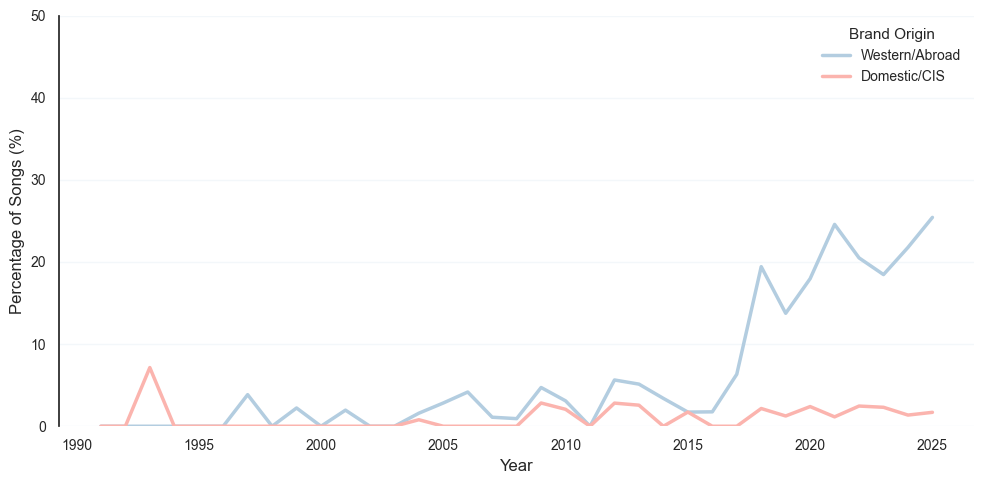

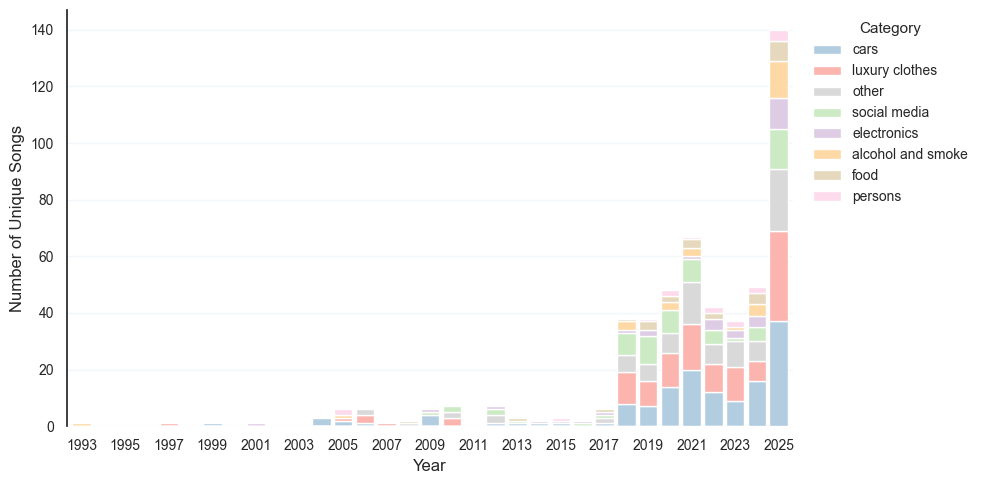

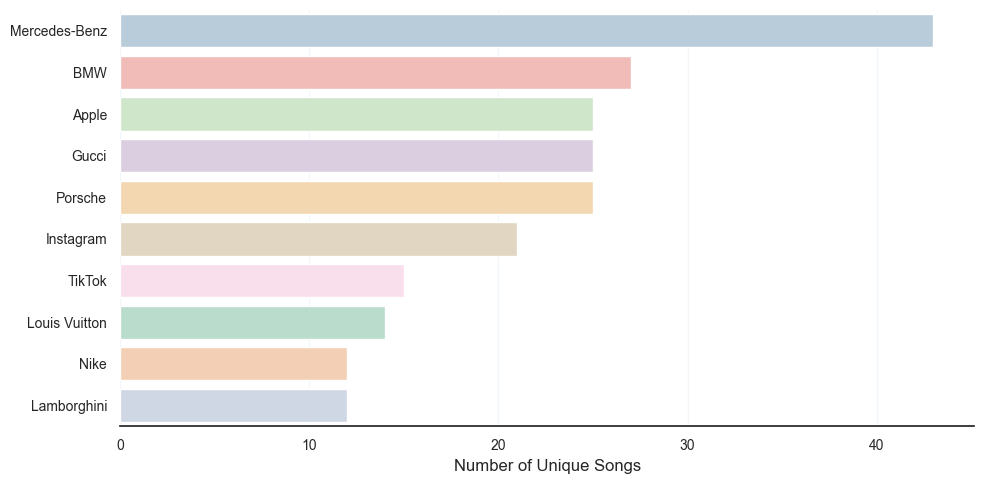

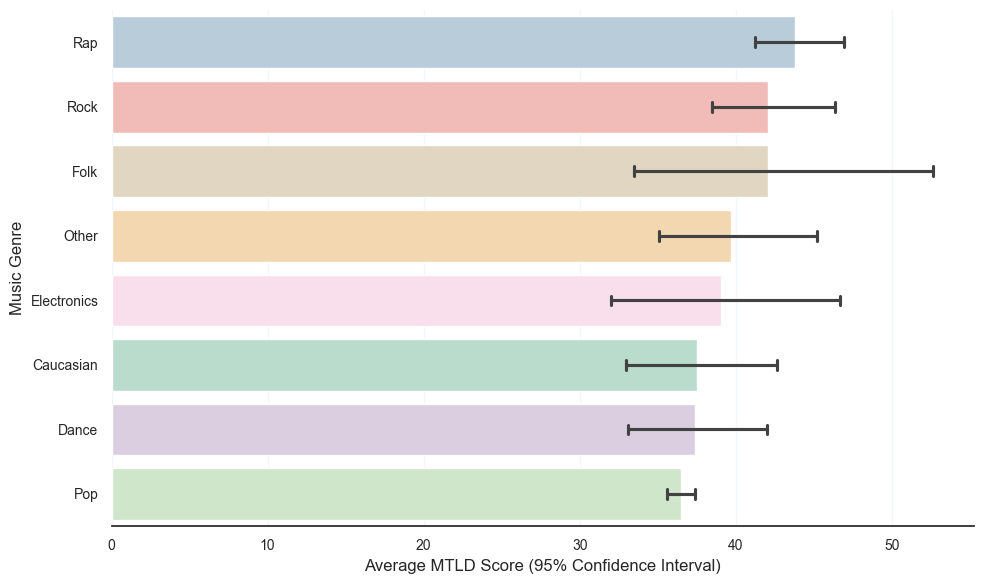

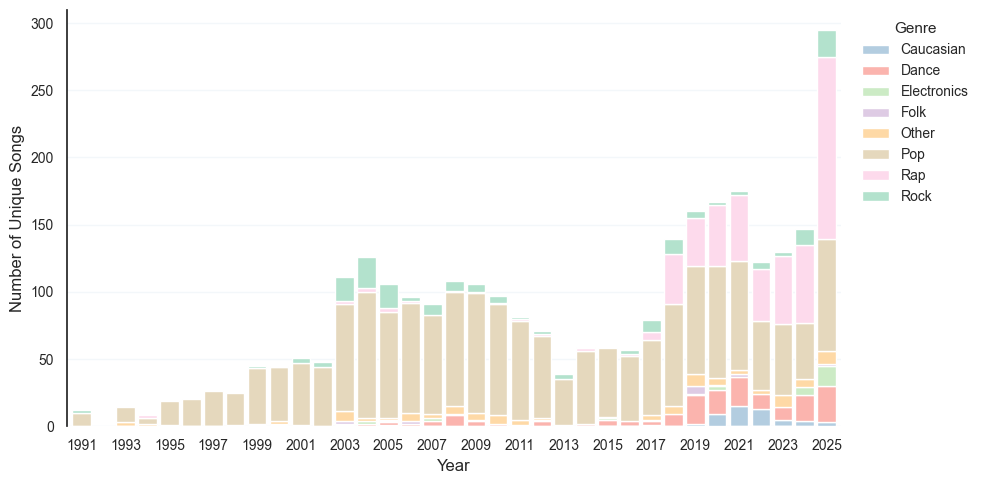

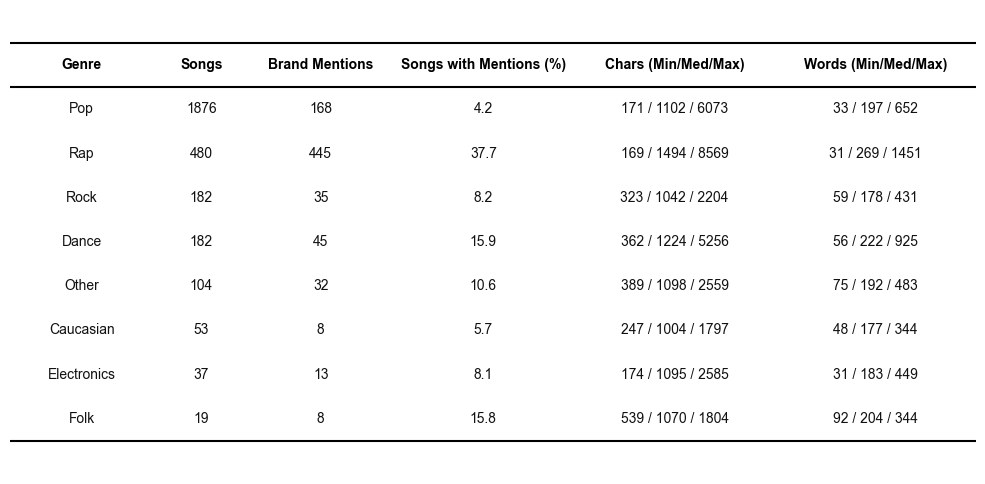

In [28]:
# styling
set_minimalist_style()

# data path
data_path = '../dashboard_data/df_genres v2.csv' 

# initialization
if os.path.exists(data_path):
    df, df_exploded = load_and_prep_data(data_path)
    
    # rendering
    plot_brand_ratios_over_time(df)
    plot_top_categories_stacked(df_exploded)
    plot_top_10_brands(df_exploded)
    plot_mtld_by_genre(df)
    plot_songs_per_genre_over_time(df)
    plot_corpus_statistics(df, df_exploded)
else:
    print(f"error: could not find {data_path}. please update the path.")

In [9]:
df.sort_values(
    by='lyrics', 
    key=lambda col: col.astype(str).str.split().str.len(), 
    ascending=True
).head(20)

,year,platform,raw_artist,raw_song,matched_artist,matched_song,ai_suggestions,lyrics,genius_id,lrclib_id,genres_yandex,genres_musicbrainz,genres_itunes,genres_lastfm,chosen_genre,extracted_brands,mtld,parsed_brands
237,2003,radio,Демо,Новый год идёт...,Демо,Новый год идёт...,[],var d =\n'VideoSaverWindow');\n= «30px»;\n= «0...,NaN,NaN,['ruspop'],['russian'],['Pop'],"['pop', 'russian', 'Russian Pop', 'techno', 'r...",pop,[],0.000000,[]
251,2003,radio,Демо,Новый год идёт... (Remix),Демо,Новый год идёт,"[[""Демо"", ""Новый год идёт""], [""Demo"", ""Novyy g...",var d =\n'VideoSaverWindow');\n= «30px»;\n= «0...,NaN,NaN,['ruspop'],['russian'],['Pop'],"['pop', 'russian', 'Russian Pop', 'techno', 'r...",pop,[],0.000000,[]
347,2004,radio,Вирус,Новый год!,Virus,Novyy god,"[[""Virus"", ""Novyy god""], [""Virus"", ""Noviy god""...",var d =\n'VideoSaverWindow');\n= «30px»;\n= «0...,NaN,NaN,['ruspop'],"['rock', 'new wave', 'ballad', 'synth pop']",['Rock y Alternativo'],"['Avant-garde Metal', 'Progressive metal', 'Av...",pop,[],0.000000,[]
416,2005,radio,Triplex,Бой с тенью,Triplex,Бой с тенью,[],"Любовь бьёт прямо в сердце,\nСтоит тебе раскры...",NaN,NaN,"['electronics', 'dance', 'latinfolk']",[],['Hip-Hop/Rap'],"['electronic', 'russian', 'progressive trance'...",electronics,[],53.816000,[]
1838,2020,youtube,Sqwoz Bab,Ауф,Sqwoz Bab,Ауф,[],"Это пацанский мув (е)\nБратух, не обессудь, но...",NaN,987858.0,['rusrap'],"['russian', 'trap', 'russian trap', 'comedy hi...",['Hip-Hop/Rap'],"['Hip-Hop', 'russian', 'rap', 'trap', 'Russia']",rap,[],24.567500,[]
677,2009,radio,Дмитрий Колдун,Настройся на меня,Дмитрий Колдун,Настройся на меня,[],Ночь. И огни манят.\nМашины никогда не спят —\...,NaN,NaN,['ruspop'],[],['Pop'],"['pop', 'Belarusian', 'russian', 'male vocalis...",pop,[],63.000000,[]
2524,2005,song of the year,"Владимир Пресняков, Группа «Банда»",Подружка Маша,Владимир Пресняков,Подружка Маша,"[[""Владимир Пресняков"", ""Подружка Маша""], [""Vl...","Подружка Маша, Маша, Маша, Маша,\nПожалуйста, ...",NaN,NaN,['rusestrada'],"['pop', 'jazz', 'rock']",['Pop'],"['pop', 'russian', '90s', 'pop rock', 'Russia']",pop,[],10.791667,[]
615,2008,radio,Филипп Киркоров,Галки,Филипп Киркоров,Галки,[],"Река протекала под асфальтом,\nА я пел то тено...",NaN,NaN,['rusestrada'],"['estrada', 'pop', 'немного']",['Pop'],"['kircore', 'pop', 'russian', 'Russian Pop', '...",pop,[],53.235000,[]
750,2011,radio,Дима Билан,Мечтатели,Дима Билан,Мечтатели,[],"Мыстобоймечтатели,\nМытакиеразные,\nПростонепо...",NaN,NaN,['ruspop'],"['russian', 'eurovision', 'kircore']",['Pop'],"['pop', 'russian', 'Russian Pop', 'pederastcor...",pop,[],14.985502,[]
1630,2008,youtube,Нэнси,Дым сигарет с ментолом,Нэнси,Дым сигарет с ментолом,[],"Завтра я буду дома,\nЗавтра я буду пьяный,\nНо...",NaN,NaN,['rusestrada'],"['pop', 'russian pop']",['Pop'],"['pop', 'russian', '90s', 'Russian Pop', '80s-...",pop,[],22.899234,[]
